In [1]:
!pip install roboflow

In [1]:
!pip install firebase-admin

In [1]:
import os
from ultralytics import YOLO
from roboflow import Roboflow
import torch

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# 1. 確認環境
def train_model():
    # 確保顯存被清空
    torch.cuda.empty_cache()

    device = 0 if torch.cuda.is_available() else "cpu"
    print(f"正在使用顯卡: {torch.cuda.get_device_name(0)}")

    # 2. 下載資料集
    rf = Roboflow(api_key="i4ljV1xx3V2E9GFOUVG1")
    project = rf.workspace("ambatukam-sml2h").project("garbage-classification-3-6wzpl")
    version = project.version(5)
    dataset = version.download("yolov8")
                
    # 3. 獲取 data.yaml 的絕對路徑 (本地端建議用絕對路徑避免找不到圖)
    data_path = os.path.abspath(os.path.join(dataset.location, "data.yaml"))

    # 4. 載入模型
    model = YOLO('yolov8m.pt') 

    model.train(
        data=os.path.abspath(os.path.join(dataset.location, "data.yaml")),
        epochs=100,
        imgsz=640,
        batch=4,           
        device=device,
        workers=0,         # Windows 建議設 0 避免 Kernel Died
        name='3060Ti_Stable_v8m',
        amp=True           # 30 系顯卡必開，加速且省顯存
    )

# 5. 開始訓練
if __name__ == '__main__':
    train_model()

正在使用顯卡: NVIDIA GeForce RTX 3060 Ti
loading Roboflow workspace...
loading Roboflow project...
New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.13.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\lol\GARBAGE-CLASSIFICATION-3-5\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_rat


image 1/1 C:\Users\lol\Desktop\GarbagePicture\IMG_2950.jpg: 640x480 6 PLASTICs, 11.7ms
Speed: 2.1ms preprocess, 11.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\lol\runs\detect\predict32


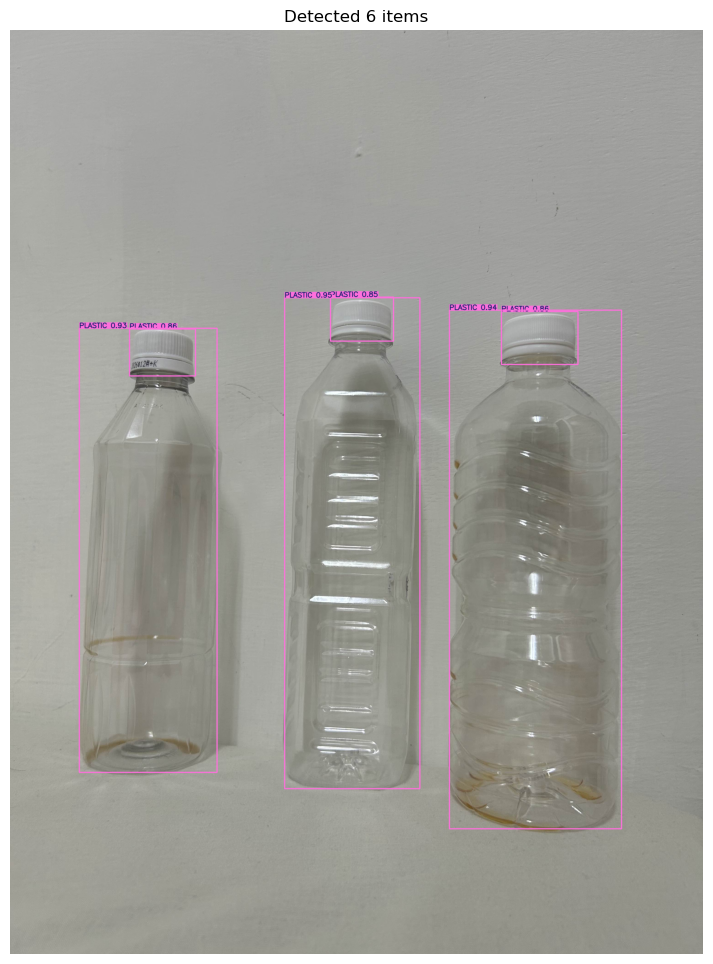

✅ 偵測結果圖已儲存至: C:\Users\lol\runs\detect\predict32


In [3]:
import os
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import torch

# 確保圖片正確顯示
%matplotlib inline

def detect_and_show_results(model_path, img_path):
    # 載入模型
    model = YOLO(model_path)

    # 執行辨識
    # 設定 save=True 會將結果存入磁碟
    results = model.predict(source=img_path, conf=0.4, save=True)

    # 處理偵測結果
    for r in results:
        # 使用 r.plot() 取得畫好框框的圖片 (BGR 格式)
        im_array = r.plot(line_width=3) 
        
        # 將 BGR 轉換為 RGB 供 matplotlib 顯示
        im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
        
        # 顯示圖片
        plt.figure(figsize=(12, 12))
        plt.imshow(im_rgb)
        plt.axis('off') # 隱藏座標軸
        plt.title(f"Detected {len(r.boxes)} items")
        plt.show() # 顯示圖表
        
        # 提示圖片儲存路徑
        print(f"✅ 偵測結果圖已儲存至: {r.save_dir}")

# === 執行 ===
my_model = 'runs/detect/3060Ti_Stable_v8m4/weights/best.pt'
my_image = r'C:/Users/lol/Desktop/GarbagePicture/IMG_2950.jpg'

detect_and_show_results(my_model, my_image)

In [1]:
import firebase_admin
from firebase_admin import credentials, db
from ultralytics import YOLO
import base64
import numpy as np
import cv2
import time

# 1. Firebase 初始化 (僅使用 Database)
cred_path = r'C:\Users\lol\Desktop\Dayu\serviceAccountKey\serviceAccountKey.json'
if not firebase_admin._apps:
    cred = credentials.Certificate(cred_path)
    firebase_admin.initialize_app(cred, {
        'databaseURL': ' '
    })

# 2. 載入模型
model = YOLO(r'runs/detect/3060Ti_Stable_v8m4/weights/best.pt')
ref = db.reference('ScanControl')

print("🚀 Base64 辨識後端已啟動！(無需 Storage)")

while True:
    current_status = ref.get()
    is_waiting = current_status.get('isWaitingForScan', False) if current_status else False
    img_base64 = current_status.get('imgData', '') if current_status else ''

    if is_waiting and img_base64:
        print("📸 接收到 Base64 圖片數據，解碼中...")
        
        try:
            # 將 Base64 字串轉回 OpenCV 格式
            img_data = base64.b64decode(img_base64)
            nparr = np.frombuffer(img_data, np.uint8)
            frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

            if frame is not None:
                # 執行辨識
                results = model.predict(source=frame, conf=0.28, verbose=False)
                
                detected_label = "None"
                for r in results:
                    if len(r.boxes) > 0:
                        class_id = int(r.boxes[0].cls[0])
                        detected_label = model.names[class_id]
                        break
                
                print(f"✅ 辨識結果：{detected_label}")

                # 回傳結果並清空圖片數據 (避免重複辨識)
                ref.update({
                    'isWaitingForScan': False,
                    'scannedResult': detected_label,
                    'imgData': '', # 清空以節省資料庫空間
                    'timestamp': time.time()
                })
            else:
                print("❌ 圖片解碼失敗")

        except Exception as e:
            print(f"❌ 錯誤: {e}")

    time.sleep(0.5)

🚀 Base64 辨識後端已啟動！(無需 Storage)
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：METAL
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：PLASTIC
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：CARDBOARD
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：PAPER
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：BIODEGRADABLE
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：PLASTIC
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：BIODEGRADABLE
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：BIODEGRADABLE
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：CARDBOARD
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：CARDBOARD
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：CARDBOARD
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：None
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：PAPER
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：PAPER
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：PAPER
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：CARDBOARD
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：CARDBOARD
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：None
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：METAL
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：METAL
📸 接收到 Base64 圖片數據，解碼中...
✅ 辨識結果：METAL


KeyboardInterrupt: 